# Бейзлайн: логистическая регрессия

Бинарная классификация `breast_cancer`, разбиение 60/20/20 со стратификацией, метрики на валидации.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "png"
plt.rcParams["figure.dpi"] = 72
from sklearn.pipeline import make_pipeline
from ml_toolkit.data import make_split
from ml_toolkit.features import make_preprocessor
from ml_toolkit.models import build_model
from ml_toolkit.metrics import calc_metrics, bootstrap_ci
from ml_toolkit.viz import plot_roc

In [2]:
split = make_split("breast_cancer", seed=42)
split.sizes()

{'train': 341, 'val': 114, 'test': 114}

## Обучение

Стандартизация признаков + `LogisticRegression(C=1.0)`.

In [3]:
model = make_pipeline(make_preprocessor(), build_model("logreg", C=1.0))
model.fit(split.X_train, split.y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pipeline', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, defaul

In [4]:
proba = model.predict_proba(split.X_val)
pred = model.predict(split.X_val)
metrics = calc_metrics(split.y_val, pred, proba)
print({k: round(v, 4) for k, v in metrics.items()})

{'accuracy': 0.9912, 'f1': 0.9906, 'roc_auc': 0.998}


In [5]:
from sklearn.metrics import f1_score
lo, hi = bootstrap_ci(lambda t, p: f1_score(t, p, average="macro"), split.y_val, pred)
print(f"F1 95% CI: [{lo:.3f}, {hi:.3f}]")

F1 95% CI: [0.970, 1.000]


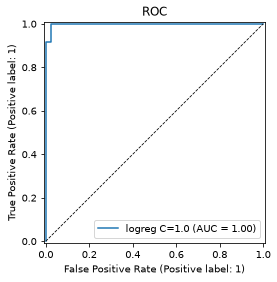

In [6]:
plot_roc(split.y_val, proba[:, 1], label="logreg C=1.0")
plt.show()

Логистическая регрессия даёт сильный бейзлайн. Следующий шаг — градиентный бустинг (`03_gradient_boosting.ipynb`).